In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/combined_vic_demand.csv')

df.tail(n=3)

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
234141,VIC1,23-03-2026 23:50,4869.36,56.5,TRADE
234142,VIC1,23-03-2026 23:55,4849.30,56.5,TRADE
234143,VIC1,24-03-2026 00:00,4816.98,56.5,TRADE


In [ ]:
df.dtypes

,0
REGION,object
SETTLEMENTDATE,object
TOTALDEMAND,float64
RRP,float64
PERIODTYPE,object


In [ ]:
df['SETTLEMENTDATE'] = pd.to_datetime(df['SETTLEMENTDATE'], format='mixed', dayfirst=True)
df = df.sort_values('SETTLEMENTDATE').reset_index(drop=True)

print(df['SETTLEMENTDATE'].min(), '→', df['SETTLEMENTDATE'].max())

2024-01-01 00:05:00 → 2026-03-24 00:00:00


In [ ]:
# ── 1. Basic info ──────────────────────────────────────────
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nBasic Stats:\n", df[['TOTALDEMAND', 'RRP']].describe())

Shape: (234144, 5)

Data Types:
 REGION                    object
SETTLEMENTDATE    datetime64[ns]
TOTALDEMAND              float64
RRP                      float64
PERIODTYPE                object
dtype: object

Basic Stats:
          TOTALDEMAND            RRP
count  234144.000000  234144.000000
mean     4791.488752      76.313908
std      1156.356760     346.746823
min      1224.770000   -1000.000000
25%      4068.327500       0.020000
50%      4681.090000      59.910000
75%      5452.665000     117.752500
max     10783.740000   17500.000000


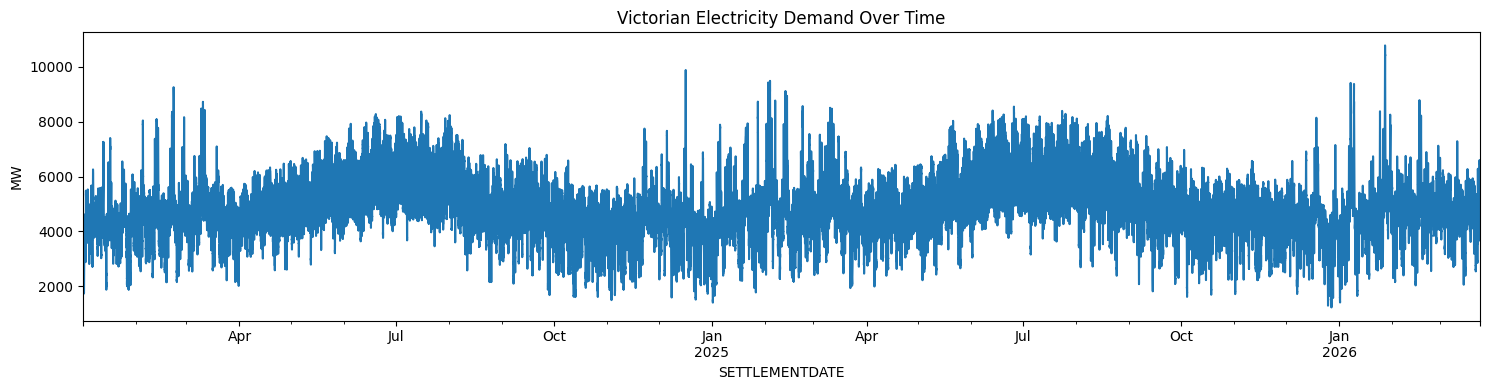

In [ ]:
# ── 2. Demand over time ────────────────────────────────────
plt.figure(figsize=(15, 4))
df.set_index('SETTLEMENTDATE')['TOTALDEMAND'].plot()
plt.title('Victorian Electricity Demand Over Time')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

Demand ranges roughly 2,000–10,000 MW
Clear seasonal cycles — winter peaks visible (Jun/Jul 2025 higher)
A few extreme spikes — likely heatwaves or cold snaps
Some very low dips — possibly data anomalies or low-demand periods worth investigating

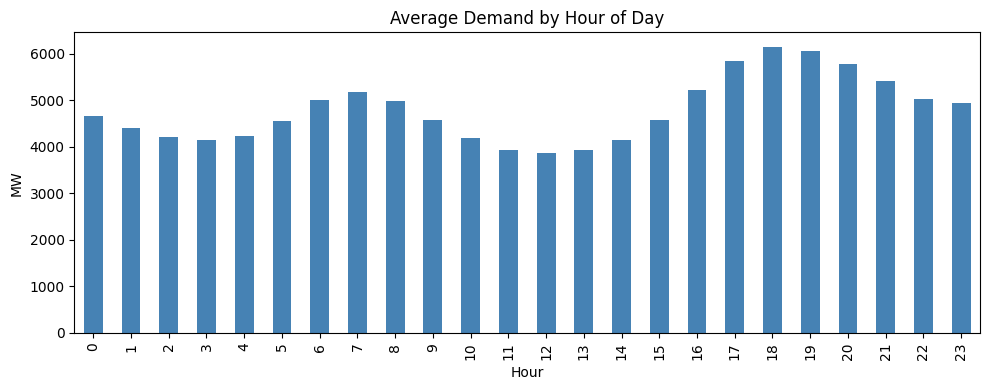

In [ ]:
# ── 3. Average demand by hour ──────────────────────────────
df['hour'] = df['SETTLEMENTDATE'].dt.hour
plt.figure(figsize=(10, 4))
df.groupby('hour')['TOTALDEMAND'].mean().plot(kind='bar', color='steelblue')
plt.title('Average Demand by Hour of Day')
plt.ylabel('MW')
plt.xlabel('Hour')
plt.tight_layout()
plt.show()

Classic dual-peak pattern:

Morning peak around 7-8am (~5,100 MW)
Evening peak around 18-19pm (~6,100 MW) ← bigger peak


Lowest demand at 11am-1pm (~3,900 MW)
This is exactly what AusNet/Powercor manage daily

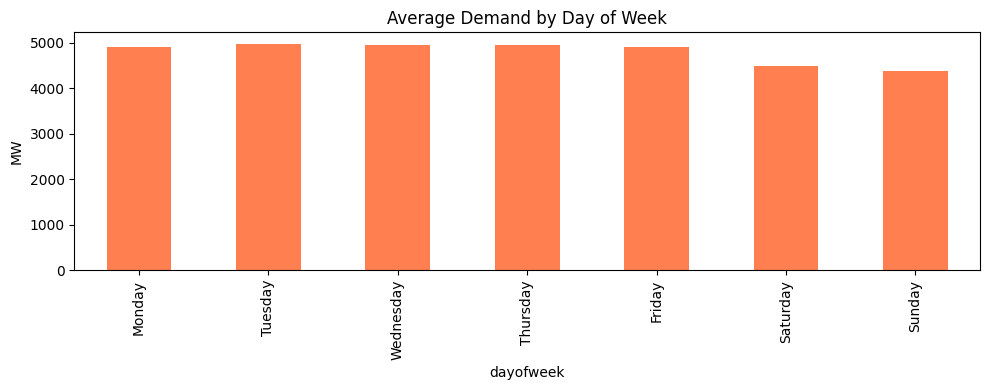

In [ ]:
# ── 4. Average demand by day of week ──────────────────────
df['dayofweek'] = df['SETTLEMENTDATE'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10, 4))
df.groupby('dayofweek')['TOTALDEMAND'].mean().reindex(day_order).plot(kind='bar', color='coral')
plt.title('Average Demand by Day of Week')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

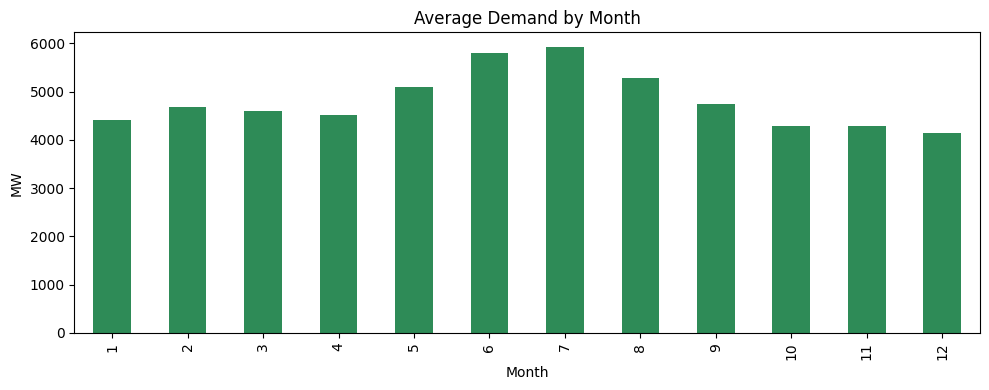

In [ ]:
# ── 5. Average demand by month ─────────────────────────────
df['month'] = df['SETTLEMENTDATE'].dt.month
plt.figure(figsize=(10, 4))
df.groupby('month')['TOTALDEMAND'].mean().plot(kind='bar', color='seagreen')
plt.title('Average Demand by Month')
plt.ylabel('MW')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

Clear winter peak June-July (~5,900 MW) — heating demand
Summer (Jan-Apr) relatively lower (~4,400-4,600 MW)
Victorian pattern confirmed — heating dominates over cooling


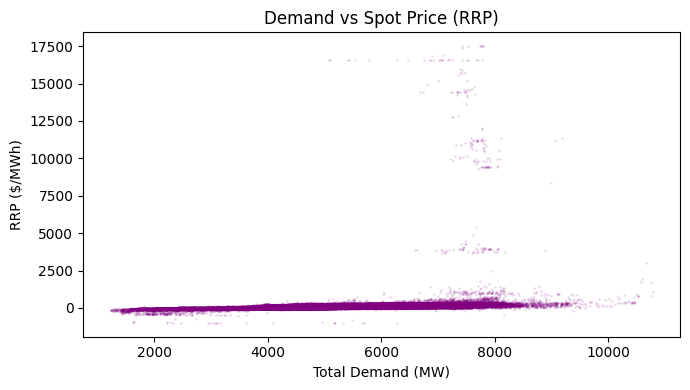


Correlation between TOTALDEMAND and RRP: 0.235


In [ ]:
# ── 6. Demand vs RRP correlation ───────────────────────────
plt.figure(figsize=(7, 4))
plt.scatter(df['TOTALDEMAND'], df['RRP'], alpha=0.1, s=1, color='purple')
plt.title('Demand vs Spot Price (RRP)')
plt.xlabel('Total Demand (MW)')
plt.ylabel('RRP ($/MWh)')
plt.tight_layout()
plt.show()

print("\nCorrelation between TOTALDEMAND and RRP:", df['TOTALDEMAND'].corr(df['RRP']).round(3))

Correlation of 0.235 — weak but meaningful
Most prices cluster near zero at normal demand
Extreme price spikes ($10,000-$17,500) only at high demand (7,000-8,000 MW) — price cap events
RRP is too noisy to use as a feature — drop it


Hour of day ✅
Month/season ✅
Lag features ✅
Weather/temperature

In [ ]:
!pip install openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 713.6/713.6 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 68.1 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
import openmeteo_requests
import pandas as pd


import openmeteo_requests
import requests_cache
from retry_requests import retry

# Setup client
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Melbourne coordinates
params = {
    "latitude": -37.8136,
    "longitude": 144.9631,
    "start_date": "2024-01-01",
    "end_date": "2026-03-24",
    "hourly": "temperature_2m",
    "timezone": "Australia/Melbourne"
}

responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
response = responses[0]

# Convert to dataframe
hourly = response.Hourly()
df_weather = pd.DataFrame({
    "timestamp": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True).tz_convert("Australia/Melbourne"),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True).tz_convert("Australia/Melbourne"),
        freq="1h",
        inclusive="left"
    ),
    "temperature": hourly.Variables(0).ValuesAsNumpy()
})

df_weather['timestamp'] = df_weather['timestamp'].dt.tz_localize(None)
print(df_weather.shape)
print(df_weather.head())

(19536, 2)
            timestamp  temperature
0 2024-01-01 00:00:00        14.40
1 2024-01-01 01:00:00        14.00
2 2024-01-01 02:00:00        13.55
3 2024-01-01 03:00:00        13.10
4 2024-01-01 04:00:00        11.70


In [ ]:
# Round SETTLEMENTDATE to nearest hour for merging
df['timestamp'] = df['SETTLEMENTDATE'].dt.round('h')

# Merge
df = df.merge(df_weather, on='timestamp', how='left')

# Check
print(df.shape)
print(df[['SETTLEMENTDATE', 'timestamp', 'TOTALDEMAND', 'temperature']].head(10))
print(df['temperature'].isnull().sum())  # should be 0

(234170, 10)
       SETTLEMENTDATE           timestamp  TOTALDEMAND  temperature
0 2024-01-01 00:05:00 2024-01-01 00:00:00      3977.10         14.4
1 2024-01-01 00:10:00 2024-01-01 00:00:00      3982.35         14.4
2 2024-01-01 00:15:00 2024-01-01 00:00:00      3965.75         14.4
3 2024-01-01 00:20:00 2024-01-01 00:00:00      3932.93         14.4
4 2024-01-01 00:25:00 2024-01-01 00:00:00      3904.02         14.4
5 2024-01-01 00:30:00 2024-01-01 00:00:00      3871.97         14.4
6 2024-01-01 00:35:00 2024-01-01 01:00:00      3913.34         14.0
7 2024-01-01 00:40:00 2024-01-01 01:00:00      3867.37         14.0
8 2024-01-01 00:45:00 2024-01-01 01:00:00      3849.37         14.0
9 2024-01-01 00:50:00 2024-01-01 01:00:00      3853.38         14.0
26


In [ ]:
# Set index
df = df.set_index('SETTLEMENTDATE')
df = df.drop(columns=['RRP', 'PERIODTYPE', 'REGION', 'timestamp'])

# Calendar features
df['hour']       = df.index.hour
df['minute']     = df.index.minute
df['dayofweek']  = df.index.dayofweek   # 0=Monday, 6=Sunday
df['month']      = df.index.month
df['quarter']    = df.index.quarter
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Lag features (5 min intervals → 12 per hour)
df['lag_1']    = df['TOTALDEMAND'].shift(1)      # 5 mins ago
df['lag_12']   = df['TOTALDEMAND'].shift(12)     # 1 hour ago
df['lag_48']   = df['TOTALDEMAND'].shift(48)     # 4 hours ago
df['lag_288']  = df['TOTALDEMAND'].shift(288)    # 24 hours ago
df['lag_2016'] = df['TOTALDEMAND'].shift(2016)   # 1 week ago

# Rolling averages
df['rolling_mean_1h']  = df['TOTALDEMAND'].shift(1).rolling(12).mean()
df['rolling_mean_24h'] = df['TOTALDEMAND'].shift(1).rolling(288).mean()

# Drop nulls created by lags
df = df.dropna().reset_index()

print(df.shape)
print(df.columns.tolist())

(232128, 16)
['SETTLEMENTDATE', 'TOTALDEMAND', 'hour', 'dayofweek', 'month', 'temperature', 'minute', 'quarter', 'is_weekend', 'lag_1', 'lag_12', 'lag_48', 'lag_288', 'lag_2016', 'rolling_mean_1h', 'rolling_mean_24h']



**Lag Features**

A lag feature is simply the demand value from a previous time step.

For example:
- `lag_288` = demand exactly 24 hours ago

**Why?** Electricity demand today at 6pm is strongly related to demand at 6pm yesterday. XGBoost has no built-in notion of time — so we manually give it this "memory" through lag features.

| Lag | Meaning | Why useful |
|-----|---------|------------|
| lag_1 | 5 mins ago | Very short term continuity |
| lag_12 | 1 hour ago | Recent trend |
| lag_48 | 4 hours ago | Within same day pattern |
| lag_288 | 24 hours ago | Same time yesterday |
| lag_2016 | 1 week ago | Same time last week ← most powerful |

---

**Rolling Averages**

A rolling average smooths out short-term noise by averaging demand over a window of past values.

For example:
- `rolling_mean_1h` = average demand over the last 1 hour
- `rolling_mean_24h` = average demand over the last 24 hours

**Why?** It captures the **trend direction** — is demand generally rising or falling right now? A single lag value can be noisy; an average is more stable.

---
> Lag features tell the model *"what was demand at this exact time before"*, rolling averages tell it *"what has the general demand level been recently"*

In [ ]:
df.tail(n=5)

,SETTLEMENTDATE,TOTALDEMAND,hour,dayofweek,month,temperature,minute,quarter,is_weekend,lag_1,lag_12,lag_48,lag_288,lag_2016,rolling_mean_1h,rolling_mean_24h
232123,2026-03-23 23:40:00,4897.27,23,0,3,18.4,40,1,0,4976.93,4945.07,6133.30,4888.78,4978.17,4937.685833,5065.007465
232124,2026-03-23 23:45:00,4915.50,23,0,3,18.4,45,1,0,4897.27,4906.45,6087.77,4895.22,4937.89,4933.702500,5065.036944
232125,2026-03-23 23:50:00,4869.36,23,0,3,18.4,50,1,0,4915.50,4821.54,6066.94,4859.13,4837.39,4934.456667,5065.107361
232126,2026-03-23 23:55:00,4849.30,23,0,3,18.4,55,1,0,4869.36,4907.72,6092.50,4870.97,4801.11,4938.441667,5065.142882
232127,2026-03-24 00:00:00,4816.98,0,1,3,18.4,0,1,0,4849.30,4879.78,6045.36,4844.26,4812.48,4933.573333,5065.067639


(232128, 16)
SETTLEMENTDATE      datetime64[ns]
TOTALDEMAND                float64
hour                         int32
dayofweek                    int32
month                        int32
temperature                float32
minute                       int32
quarter                      int32
is_weekend                   int64
lag_1                      float64
lag_12                     float64
lag_48                     float64
lag_288                    float64
lag_2016                   float64
rolling_mean_1h            float64
rolling_mean_24h           float64
dtype: object
SETTLEMENTDATE      0
TOTALDEMAND         0
hour                0
dayofweek           0
month               0
temperature         0
minute              0
quarter             0
is_weekend          0
lag_1               0
lag_12              0
lag_48              0
lag_288             0
lag_2016            0
rolling_mean_1h     0
rolling_mean_24h    0
dtype: int64

Correlation with TOTALDEMAND:
 TOTALDEMAND     

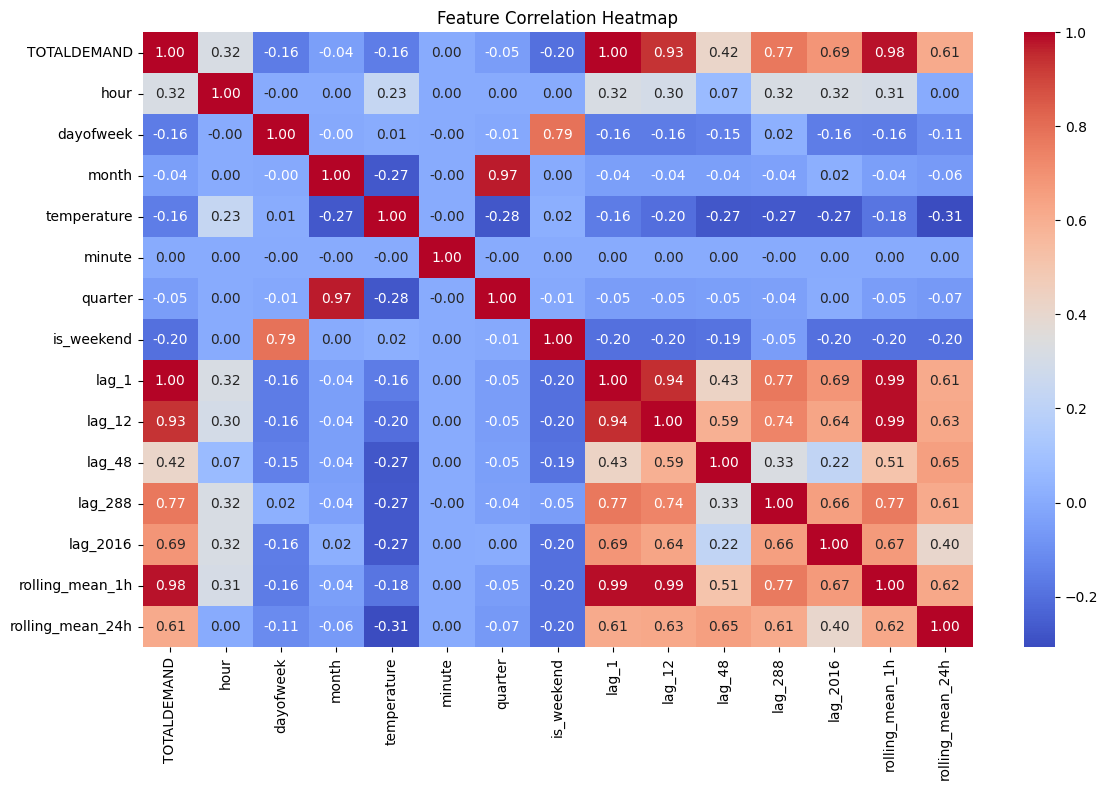

In [ ]:
# 1. Basic check
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# 2. Correlation of all features with TOTALDEMAND
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.drop(columns=['SETTLEMENTDATE']).corr()['TOTALDEMAND'].sort_values(ascending=False)
print("\nCorrelation with TOTALDEMAND:\n", corr)

# 3. Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['SETTLEMENTDATE']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Very Strong (>0.9) — Most powerful features

lag_1 (0.998) — 5 mins ago is almost identical to now, makes sense
rolling_mean_1h (0.979) — recent average is very predictive
lag_12 (0.934) — 1 hour ago still very strong


Strong (0.6-0.9)

lag_288 (0.772) — yesterday same time ✅
lag_2016 (0.685) — last week same time ✅
rolling_mean_24h (0.611) — 24hr average trend ✅


Moderate — Still useful

lag_48 (0.416) — 4 hours ago
hour (0.317) — time of day matters ✅
temperature (-0.156) — negative = higher demand in cold weather ✅ makes sense for Victoria
dayofweek (-0.163) — weekends lower demand ✅
is_weekend (-0.200) — confirms weekends lower ✅


Drop these — useless:

minute (0.000002) — zero correlation, drop it
month (-0.044) — very weak, drop it
quarter (-0.047) — very weak, drop it

in linear models (Linear Regression, Logistic Regression) high correlation between features causes problems.
But XGBoost is different:

XGBoost is a tree-based model
Trees split on one feature at a time
Multicollinearity doesn't affect it mathematically
It will naturally pick the most useful one and ignore redundant ones
That's why feature importance is so valuable with XGBoost


So the rule is:
ModelDrop high correlated features?Linear/Logistic Regression✅ YesXGBoost / Random Forest❌ No needNeural NetworksSometimes

In our case:

lag_1 and rolling_mean_1h are both highly correlated with each other AND with target
We keep both — XGBoost will just lean on whichever is more useful at each split
No harm done

In [ ]:
df = df.drop(columns=['minute', 'month', 'quarter'])

MODELLING

In [ ]:
features = [col for col in df.columns if col not in ['SETTLEMENTDATE', 'TOTALDEMAND']]
target = 'TOTALDEMAND'

print("Features:", features)
print("Total features:", len(features))

Features: ['hour', 'dayofweek', 'temperature', 'is_weekend', 'lag_1', 'lag_12', 'lag_48', 'lag_288', 'lag_2016', 'rolling_mean_1h', 'rolling_mean_24h']
Total features: 11


In [ ]:
# Use last 2 months as test
split_date = '2026-01-01'

train = df[df['SETTLEMENTDATE'] < split_date]
test  = df[df['SETTLEMENTDATE'] >= split_date]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Train: {X_train.shape} | {train['SETTLEMENTDATE'].min()} → {train['SETTLEMENTDATE'].max()}")
print(f"Test:  {X_test.shape}  | {test['SETTLEMENTDATE'].min()} → {test['SETTLEMENTDATE'].max()}")

Train: (208511, 11) | 2024-01-08 00:05:00 → 2025-12-31 23:55:00
Test:  (23617, 11)  | 2026-01-01 00:00:00 → 2026-03-24 00:00:00


In [ ]:
!pip install xgboost

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=100)b

[0]	validation_0-rmse:1058.33178
[100]	validation_0-rmse:79.52123
[200]	validation_0-rmse:79.91146
[300]	validation_0-rmse:80.24954
[400]	validation_0-rmse:80.97183
[499]	validation_0-rmse:81.17549


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE:  44.38 MW
RMSE: 81.18 MW
MAPE: 0.97%


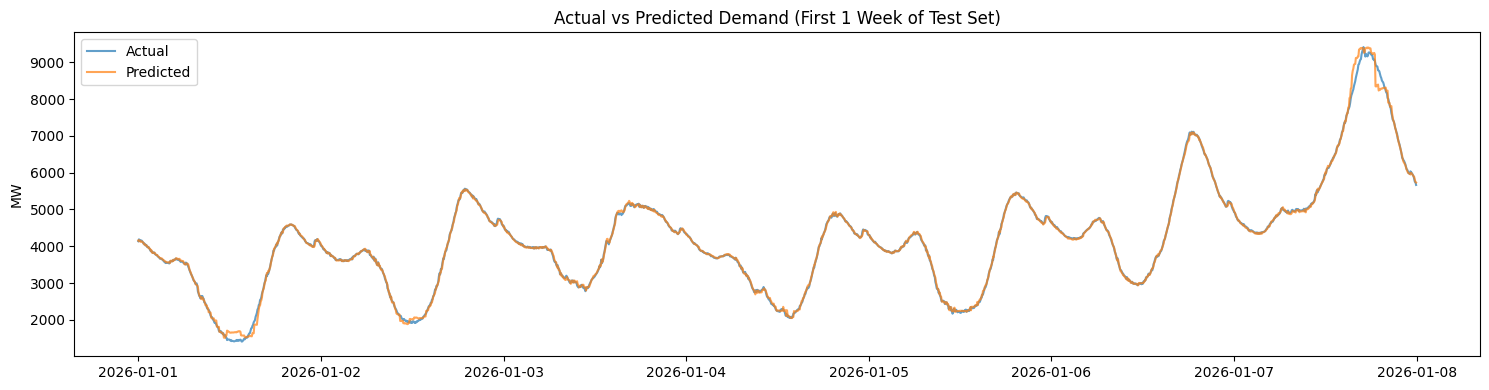

In [ ]:
plt.figure(figsize=(15, 4))
plt.plot(test['SETTLEMENTDATE'].values[:2016], y_test.values[:2016], label='Actual', alpha=0.7)
plt.plot(test['SETTLEMENTDATE'].values[:2016], y_pred[:2016], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Demand (First 1 Week of Test Set)')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Naive baseline = same time last week
baseline_mae  = mean_absolute_error(y_test, test['lag_2016'])
baseline_mape = np.mean(np.abs((y_test - test['lag_2016']) / y_test)) * 100

print(f"Baseline MAE:  {baseline_mae:.2f} MW")
print(f"Baseline MAPE: {baseline_mape:.2f}%")
print(f"XGBoost MAE:   {mae:.2f} MW")
print(f"XGBoost MAPE:  {mape:.2f}%")
print(f"Improvement:   {((baseline_mae - mae) / baseline_mae * 100):.1f}%")

Baseline MAE:  799.04 MW
Baseline MAPE: 17.34%
XGBoost MAE:   44.38 MW
XGBoost MAPE:  0.97%
Improvement:   94.4%


lag_1 — dominates, 5 mins ago is the strongest signal
rolling_mean_1h — recent average very important
lag_12 — 1 hour ago still strong
hour — time of day matters ✅
temperature — present and contributing ✅
is_weekend + dayofweek — behavioural patterns captured ✅

Built a short-term Victorian electricity demand forecasting model using AEMO 5-minute interval data. Engineered lag, rolling, calendar and temperature features and trained an XGBoost model — achieving MAPE of 0.97% and MAE of 44 MW, a 94% improvement over a naive baseline.

<Figure size 1000x600 with 0 Axes>

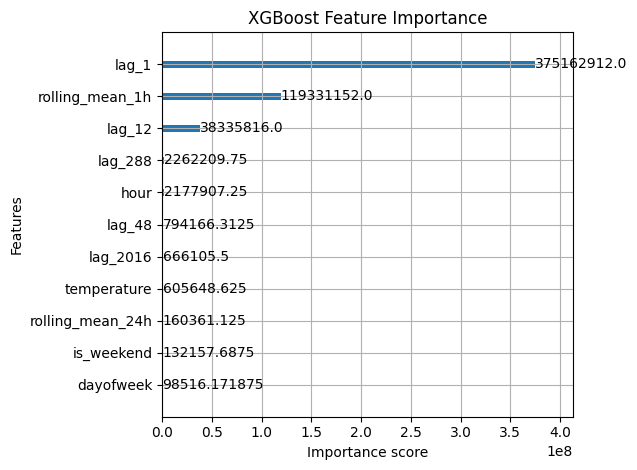

In [ ]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

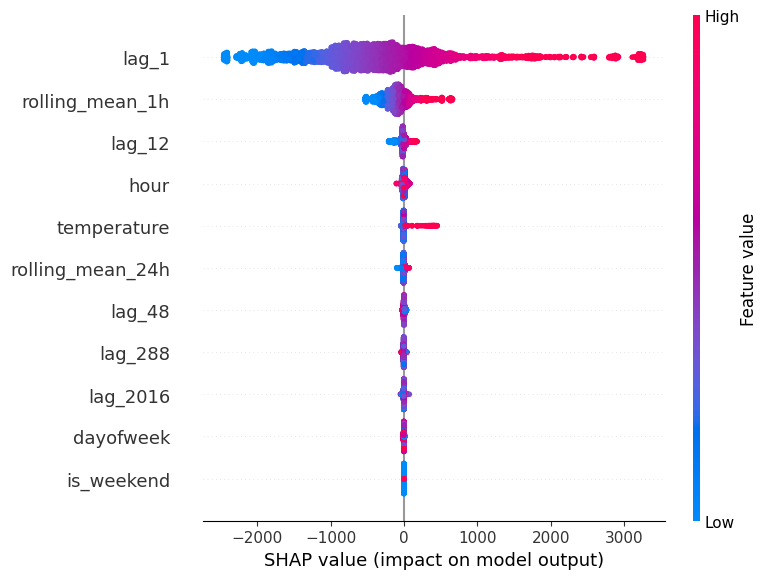

In [ ]:
!pip install shap

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:5000])

plt.figure()
shap.summary_plot(shap_values, X_test[:5000])

lag_1 — most impactful by far

Red dots (high recent demand) push prediction up ✅
Blue dots (low recent demand) push prediction down ✅
Makes perfect sense

temperature — very interesting

Red dots (high temperature) push prediction up → hot days = AC usage spike
Blue dots (low temperature) also push up slightly → cold days = heating spike
Both extremes drive demand — classic Victorian pattern ✅

hour — consistent moderate impact

Captures morning/evening peak patterns ✅

is_weekend + dayofweek — small but present

Weekends consistently lower demand ✅


 used SHAP to explain model predictions. The most impactful feature was lag_1 — recent demand is the strongest predictor. Temperature showed a two-directional effect, with both heat and cold driving demand up, which aligns with Victoria's climate patterns.

In [ ]:
# Fix - rename to model_prophet and rerun
model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
model_prophet.fit(df_prophet[df_prophet['ds'] < '2026-01-01'])

# Predict on test period only
test_prophet  = df_prophet[df_prophet['ds'] >= '2026-01-01']
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='5min')
forecast = model_prophet.predict(future)
forecast_test = forecast[forecast['ds'] >= '2026-01-01']

# Metrics
y_actual_prophet = test_prophet['y'].values
y_pred_prophet   = forecast_test['yhat'].values[:len(y_actual_prophet)]

mae_prophet  = mean_absolute_error(y_actual_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_actual_prophet, y_pred_prophet))
mape_prophet = np.mean(np.abs((y_actual_prophet - y_pred_prophet) / y_actual_prophet)) * 100

print("=" * 40)
print(f"{'Model':<20} {'MAE':>10} {'MAPE':>10}")
print("-" * 40)
print(f"{'Naive Baseline':<20} {799.04:>10.2f} {17.34:>9.2f}%")
print(f"{'Prophet':<20} {mae_prophet:>10.2f} {mape_prophet:>9.2f}%")
print(f"{'XGBoost':<20} {44.38:>10.2f} {0.97:>9.2f}%")
print("=" * 40)

Model                       MAE       MAPE
----------------------------------------
Naive Baseline           799.04     17.34%
Prophet                 1366.83     30.43%
XGBoost                   44.38      0.97%


Prophet underperformed even the naive baseline at 5-minute resolution (MAPE 30%), likely due to its design for lower-frequency data. XGBoost with engineered lag and temperature features achieved 0.97% MAPE — demonstrating that domain-specific feature engineering outperforms out-of-the-box solutions for high-frequency energy data

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# ── 1. Prepare data ─────────────────────────────────────────
# Use same train/test split
train_lstm = df[df['SETTLEMENTDATE'] < '2026-01-01']['TOTALDEMAND'].values
test_lstm  = df[df['SETTLEMENTDATE'] >= '2026-01-01']['TOTALDEMAND'].values

# Scale to 0-1
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_lstm.reshape(-1, 1))
test_scaled  = scaler.transform(test_lstm.reshape(-1, 1))

# ── 2. Create sequences ─────────────────────────────────────
def create_sequences(data, seq_length=288):  # 288 = 24 hours of 5-min data
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = create_sequences(train_scaled)
X_test_lstm,  y_test_lstm  = create_sequences(test_scaled)

# Reshape for LSTM [samples, timesteps, features]
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm  = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

print(f"X_train: {X_train_lstm.shape}")
print(f"X_test:  {X_test_lstm.shape}")

# ── 3. Build LSTM ───────────────────────────────────────────
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(288, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

# ── 4. Train ────────────────────────────────────────────────
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# ── 5. Predict & Evaluate ───────────────────────────────────
y_pred_lstm = model_lstm.predict(X_test_lstm)

# Inverse scale
y_pred_lstm  = scaler.inverse_transform(y_pred_lstm).flatten()
y_actual_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

mae_lstm  = mean_absolute_error(y_actual_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_actual_lstm, y_pred_lstm))
mape_lstm = np.mean(np.abs((y_actual_lstm - y_pred_lstm) / y_actual_lstm)) * 100

print(f"\nLSTM MAE:  {mae_lstm:.2f} MW")
print(f"LSTM RMSE: {rmse_lstm:.2f} MW")
print(f"LSTM MAPE: {mape_lstm:.2f}%")

# ── 6. Final comparison ─────────────────────────────────────
print("\n" + "=" * 40)
print(f"{'Model':<20} {'MAE':>10} {'MAPE':>10}")
print("-" * 40)
print(f"{'Naive Baseline':<20} {799.04:>10.2f} {17.34:>9.2f}%")
print(f"{'Prophet':<20} {1366.83:>10.2f} {30.43:>9.2f}%")
print(f"{'LSTM':<20} {mae_lstm:>10.2f} {mape_lstm:>9.2f}%")
print(f"{'XGBoost':<20} {44.38:>10.2f} {0.97:>9.2f}%")
print("=" * 40)

X_train: (208223, 288, 1)
X_test:  (23329, 288, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 288, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 288, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - loss: 0.0032 - val_loss: 4.3960e-04
Epoch 2/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0012 - val_loss: 2.1130e-04
Epoch 3/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 6.9202e-04 - val_loss: 1.5068e-04
Epoch 4/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 4.1301e-04 - val_loss: 1.6410e-04
Epoch 5/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 2.9916e-04 - val_loss: 1.9684e-04
Epoch 6/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 2.5655e-04 - val_loss: 1.4829e-04
Epoch 7/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 2.4223e-04 - val_loss: 7.7697e-05
Epoch 8/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 2.3178e-04 - val_loss: 6.9052e-05
Epoch 9/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 2.2660e-04 - val_loss: 6.3621e-05
Epoch 10/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 2.2424e-04 - val_loss: 5.7500e-05
730/730 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step

LSTM 

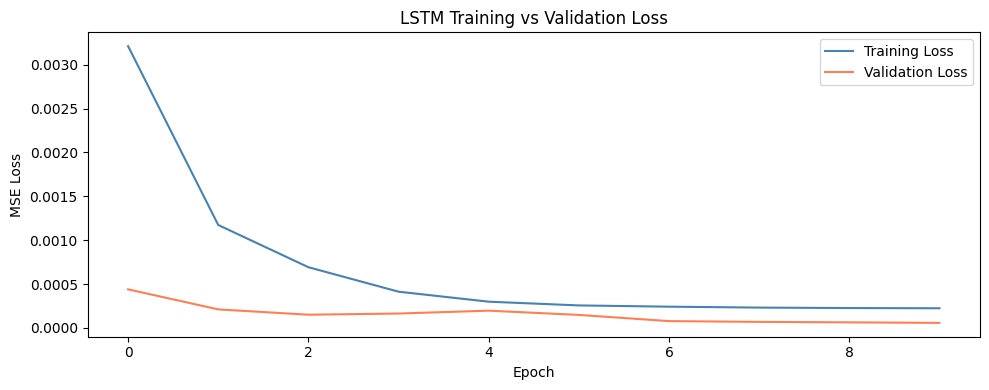

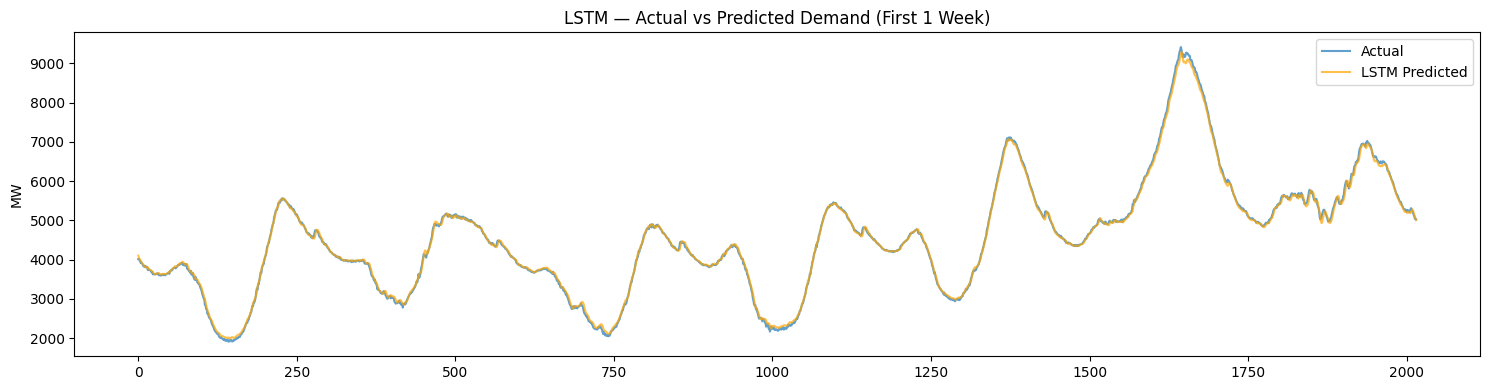

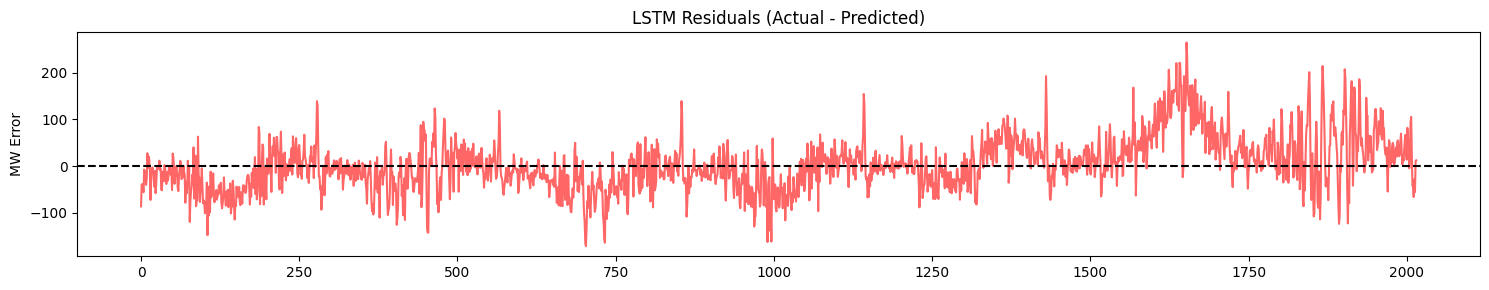

In [ ]:
# ── Plot 1: Training vs Validation Loss ────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: Actual vs Predicted ─────────────────────────────
plt.figure(figsize=(15, 4))
plt.plot(y_actual_lstm[:2016], label='Actual', alpha=0.7)
plt.plot(y_pred_lstm[:2016], label='LSTM Predicted', alpha=0.7, color='orange')
plt.title('LSTM — Actual vs Predicted Demand (First 1 Week)')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

# ── Plot 3: Residuals ───────────────────────────────────────
residuals = y_actual_lstm - y_pred_lstm
plt.figure(figsize=(15, 3))
plt.plot(residuals[:2016], color='red', alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.title('LSTM Residuals (Actual - Predicted)')
plt.ylabel('MW Error')
plt.tight_layout()
plt.show()